# Machine Learning Classification with PyCaret

## 1. Import Required Libraries and Check Version

In [1]:
# Check PyCaret version
from pycaret.utils import version
version()

'3.2.0'

In [2]:
import pandas as pd
import os
from pycaret.classification import *

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load and Explore the Dataset

In [3]:
# Load the ECFP fingerprint data
data_path = 'fp-gen/ecfp/HsDHODH-curated_ecfp_diam4_2048bits.csv'

# Check if file exists
if os.path.exists(data_path):
    print(f"✓ Found dataset: {data_path}")
    data = pd.read_csv(data_path)
    print(f"Dataset shape: {data.shape}")
else:
    print(f"⚠ Dataset not found: {data_path}")
    print("Please ensure the fingerprint generation has been completed")

✓ Found dataset: fp-gen/ecfp/HsDHODH-curated_ecfp_diam4_2048bits.csv
Dataset shape: (1792, 2050)


In [4]:
# Display basic information about the dataset
print("Dataset Info:")
print("=" * 50)
print(f"Number of rows: {data.shape[0]}")
print(f"Number of columns: {data.shape[1]}")
print(f"Columns: {list(data.columns[:5])}... (showing first 5)")

# Display first few rows
print("\nFirst 5 rows:")
display_cols = ['SMILES', 'Outcome'] + list(data.columns[2:7])  # First 5 fingerprint bits
print(data[display_cols].head())

Dataset Info:
Number of rows: 1792
Number of columns: 2050
Columns: ['SMILES', 'Outcome', '0', '1', '2']... (showing first 5)

First 5 rows:
                                              SMILES  Outcome  0  1  2  3  4
0  C=c1[nH]n(-c2ccccc2)c(=O)c1=Cc1ccc(-c2cccc(C(=...      0.0  0  0  0  0  0
1  CCC(=O)C(C#N)C(=O)Nc1ccc(-c2ccc(F)nc2)c(C(=O)O...      1.0  0  1  0  0  0
2      O=C1C(O)=C(Nc2cccc(C(F)(F)F)c2)C(=O)c2ccccc21      1.0  0  1  0  0  0
3  CCCn1c(CO)nn(-c2cc(OC(C)C(F)(F)F)c(C(=O)Nc3c(F...      1.0  0  1  0  0  0
4         COc1cccc(-c2cc(F)c(Nc3ncccc3C(=O)O)cc2F)c1      1.0  0  0  0  0  0


## 3. Data Preprocessing

In [5]:
# Prepare data for PyCaret
print("Preparing data for machine learning...")

# Remove SMILES column as it's not needed for ML (keep only Outcome and fingerprint bits)
if 'SMILES' in data.columns:
    ml_data = data.drop('SMILES', axis=1)
    print("✓ Removed SMILES column")
else:
    ml_data = data.copy()

print(f"Final dataset shape for ML: {ml_data.shape}")
print(f"Features: {ml_data.shape[1] - 1} fingerprint bits")
print(f"Target: Outcome")

Preparing data for machine learning...
✓ Removed SMILES column
Final dataset shape for ML: (1792, 2049)
Features: 2048 fingerprint bits
Target: Outcome


In [6]:
# Check data types and basic statistics
print("Data Types Summary:")
print(ml_data.dtypes.value_counts())

print(f"\nTarget variable unique values: {ml_data['Outcome'].unique()}")
print(f"Number of unique classes: {ml_data['Outcome'].nunique()}")

Data Types Summary:
int64      2048
float64       1
dtype: int64

Target variable unique values: [0. 1.]
Number of unique classes: 2


In [7]:
from sklearn.model_selection import train_test_split

# Stratified split of ml_data into train (70%) and test (30%) sets
train_data, test_data = train_test_split(
    ml_data,
    test_size=0.2,
    stratify=ml_data['Outcome'],
    random_state=143
)

print(f"Train set shape: {train_data.shape}")
print(f"Test set shape: {test_data.shape}")
print(f"Train Outcome distribution:\n{train_data['Outcome'].value_counts(normalize=True)}")
print(f"Test Outcome distribution:\n{test_data['Outcome'].value_counts(normalize=True)}")

Train set shape: (1433, 2049)
Test set shape: (359, 2049)
Train Outcome distribution:
1.0    0.597348
0.0    0.402652
Name: Outcome, dtype: float64
Test Outcome distribution:
1.0    0.598886
0.0    0.401114
Name: Outcome, dtype: float64


## 4. Pycaret Setup

In [8]:
# Setup PyCaret classification environment
print("Setting up PyCaret classification environment...")
print("This may take a moment...")

clf1 = setup(data=train_data, 
    target='Outcome', 
    session_id=143,
    remove_multicollinearity=False,
    fix_imbalance=False,
    fold_strategy='stratifiedkfold',
    experiment_custom_tags={'Project': 'H3D_HsDHODH', 'Type': 'Classification'},
    experiment_name='HsDHODH_ECFP_diam6_2048bits',
    log_plots=True,  
    log_data=True,  
    log_profile=True,  
    train_size=0.8,
    use_gpu=False,
    preprocess=False
)

Setting up PyCaret classification environment...
This may take a moment...


,Description,Value
0,Session id,143
1,Target,Outcome
2,Target type,Binary
3,Original data shape,"(1433, 2049)"
4,Transformed data shape,"(1433, 2049)"
5,Transformed train set shape,"(1146, 2049)"
6,Transformed test set shape,"(287, 2049)"
7,Numeric features,2048


In [9]:
# Compare different classification algorithms
print("Comparing multiple classification models...")
print("This will train and evaluate various algorithms using cross-validation")

best_models = compare_models(
    include=['lr', 'rf', 'et', 'xgboost', 'nb', 'svm', 'knn', 'dummy'],
    sort='Accuracy',
    n_select=10,  
    verbose=True
)

Comparing multiple classification models...
This will train and evaluate various algorithms using cross-validation


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.8700,0.9370,0.9126,0.8762,0.8932,0.7271,0.7304,0.6410
xgboost,Extreme Gradient Boosting,0.8700,0.9345,0.9140,0.8750,0.8933,0.7269,0.7305,0.5010
rf,Random Forest Classifier,0.8691,0.9380,0.9256,0.8656,0.8937,0.7236,0.7297,0.5590
et,Extra Trees Classifier,0.8622,0.9365,0.9097,0.8668,0.8870,0.7105,0.7144,0.3470
knn,K Neighbors Classifier,0.8613,0.9164,0.9271,0.8543,0.8888,0.7052,0.7107,0.0370
svm,SVM - Linear Kernel,0.8412,0.0000,0.8921,0.8519,0.8696,0.6662,0.6724,0.0400
nb,Naive Bayes,0.7914,0.8047,0.8322,0.8227,0.8258,0.5653,0.5689,0.0280
dummy,Dummy Classifier,0.5977,0.5000,1.0000,0.5977,0.7482,0.0000,0.0000,0.0170


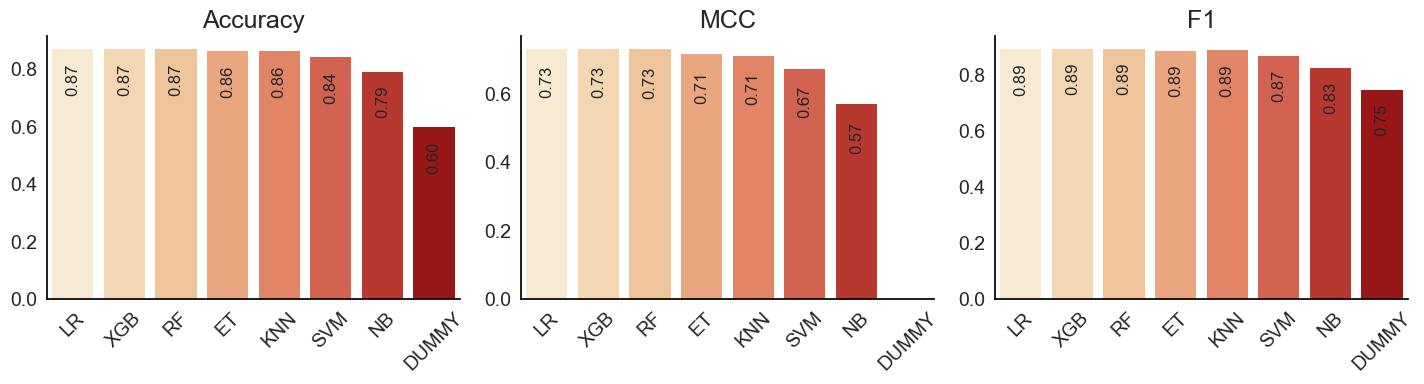

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
# Pull the latest cross-validation metrics from PyCaret and select metrics
metrics_df = pull().copy()
metrics_to_plot = ['Accuracy', 'MCC', 'F1']
metrics_df = metrics_df[metrics_to_plot]

# Map model acronyms to desired uppercase labels
mapping = {'et': 'ET', 'rf': 'RF', 'xgboost': 'XGB', 'lr': 'LR',
           'knn': 'KNN', 'svm': 'SVM', 'nb': 'NB', 'dummy': 'DUMMY'}

# Add Model column with mapped labels and preserve plotting order
metrics_df['Model'] = metrics_df.index.map(lambda x: mapping.get(x, x))
model_order = [mapping.get(x, x) for x in metrics_df.index]

# Melt for seaborn
metrics_long = metrics_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
metrics_long['Model'] = pd.Categorical(metrics_long['Model'], categories=model_order, ordered=True)

# Plot
g = sns.FacetGrid(metrics_long, col='Metric', col_wrap=3, height=4, aspect=1.2, sharey=False)
g.map(sns.barplot, 'Model', 'Score', palette='OrRd', order=model_order)

# Set titles and style
for ax, title in zip(g.axes.flat, g.col_names):
    ax.set_title(title, fontsize=18)

for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=45, labelsize=14)
    ax.tick_params(axis='y', labelsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_facecolor('white')
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('black')
    ax.spines['bottom'].set_color('black')
    for p in ax.patches:
        h = p.get_height()
        if h is not None and h > 0:
            ax.text(p.get_x() + p.get_width()/2., h - 0.05, f'{h:.2f}',
                    ha='center', va='top', fontsize=12, rotation=90)

plt.tight_layout()
plt.show()

## 6. Create Individual Models

In [14]:
# Create the best performing model (XGBoost as default)
print("Creating XGBoost model...")
xgb_model = create_model('xgboost')

Creating XGBoost model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8885,0.8116,0.8485,0.8296,0.5878,0.5887
1,0.8696,0.9483,0.9275,0.8649,0.8951,0.7232,0.7263
2,0.9304,0.9688,0.9710,0.9178,0.9437,0.8529,0.8553
3,0.8957,0.9546,0.8986,0.9254,0.9118,0.7842,0.7847
4,0.8435,0.9064,0.8696,0.8696,0.8696,0.6739,0.6739
5,0.8609,0.9093,0.8971,0.8714,0.8841,0.7102,0.7107
6,0.8772,0.9645,0.9853,0.8375,0.9054,0.7336,0.7535
7,0.8333,0.9236,0.8971,0.8356,0.8652,0.6476,0.6504
8,0.8772,0.9150,0.9412,0.8649,0.9014,0.7394,0.7440


## 7. Tunning individual models

In [18]:
# Tune hyperparameters for the best model
print("Tuning XGB hyperparameters...")
tunned_xgb = tune_model(xgb_model, round=4, n_iter=20, search_library='optuna')
print(f"XGB model shape - Features: {tunned_xgb.n_features_in_}, Classes: {tunned_xgb.n_classes_}")

Tuning XGB hyperparameters...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.8000,0.8689,0.8986,0.7949,0.8435,0.5693,0.5776
1,0.8348,0.9319,0.9710,0.7976,0.8758,0.6360,0.6640
2,0.8696,0.9606,1.0000,0.8214,0.9020,0.7126,0.7440
3,0.8957,0.9537,0.9420,0.8904,0.9155,0.7794,0.7815
4,0.8261,0.9156,0.9130,0.8182,0.8630,0.6269,0.6340
5,0.8435,0.9233,0.9118,0.8378,0.8732,0.6696,0.6737
6,0.8596,0.9773,1.0000,0.8095,0.8947,0.6911,0.7266
7,0.8246,0.9281,0.9706,0.7857,0.8684,0.6138,0.6454
8,0.8596,0.9309,1.0000,0.8095,0.8947,0.6911,0.7266


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
XGB model shape - Features: 2048, Classes: 2


## 8. Generate Predictions 

In [19]:
# Generate predictions on test set
print("Generating predictions...")
predictions = predict_model(tunned_xgb, data=test_data)
print("Predictions shape:", predictions.shape)
print("\nFirst 10 predictions:")

Generating predictions...


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extreme Gradient Boosting,0.8579,0.9426,0.8837,0.8796,0.8817,0.7040,0.7040


Predictions shape: (359, 2051)

First 10 predictions:


## 9. Model Evaluation and Tuning

In [20]:
# Evaluate the tuned model
print("Evaluating tuned Extreme Gradient Boosting model...")
evaluate_model(tunned_xgb)

Evaluating tuned Extreme Gradient Boosting model...


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

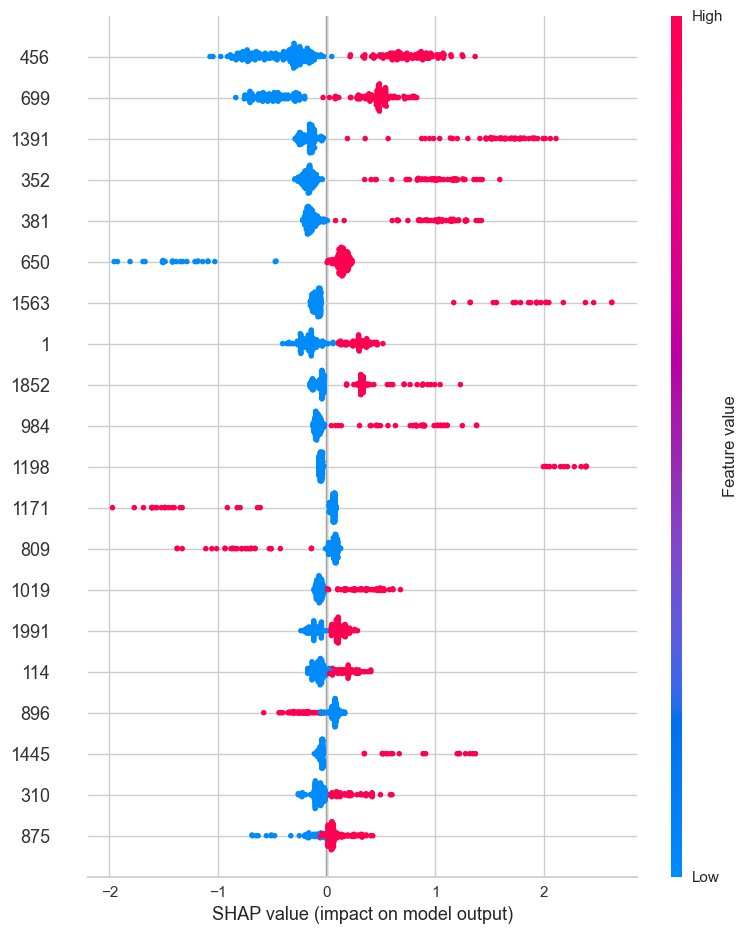

In [21]:
interpret_model(tunned_xgb)

## 10. Save Models

In [ ]:
# Save the final model
print("Saving the final model...")
save_model(tunned_xgb, 'HsDHODH_ECFP_diam6_2048bits_final_model_xgb')
print("✓ Model saved successfully!")

Saving the final model...
Transformation Pipeline and Model Successfully Saved
✓ Model saved successfully!


## Pipeline Summary
This notebook demonstrates a complete automated machine learning pipeline using PyCaret for molecular classification with multiple fingerprint types:

Key Steps:
1. Data Loading: Automatically load all fingerprint datasets (ECFP, FCFP, MACCS)
2. Data Exploration: Analyze each dataset's characteristics
3. Train-Test Split: Stratified split for each dataset
4. Model Comparison: Compare 8 classification algorithms per dataset
5. Model Training: Train and tune Random Forest and Extra Trees models
6. Model Evaluation: Cross-validation and test set evaluation
7. Model Saving: Save all trained models with descriptive names

Generated Outputs:
- Trained models for each fingerprint type (RF and ET)
- Complete experiment logs with MLflow
- Performance metrics for all models

- Test set predictions for each datasetThe pipeline processes multiple datasets automatically, making it easy to compare performance across different molecular fingerprint representations for QSAR analysis.

- Comprehensive results summary